In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [16]:
df.duplicated().sum()

np.int64(1)

In [17]:
df.drop_duplicates(inplace = True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(302, 14)

In [20]:
#Value counts - To check target column for the count of ppl having Heart diseases and do not have heart diseases
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

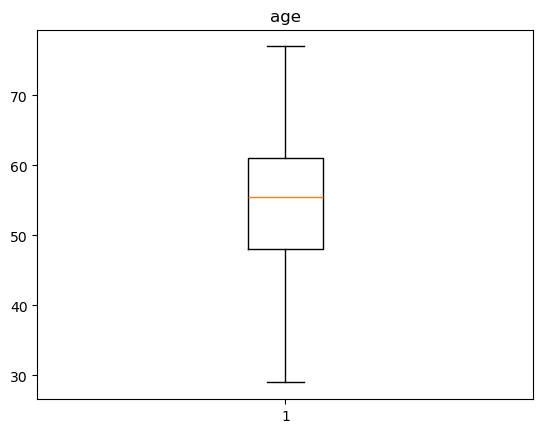

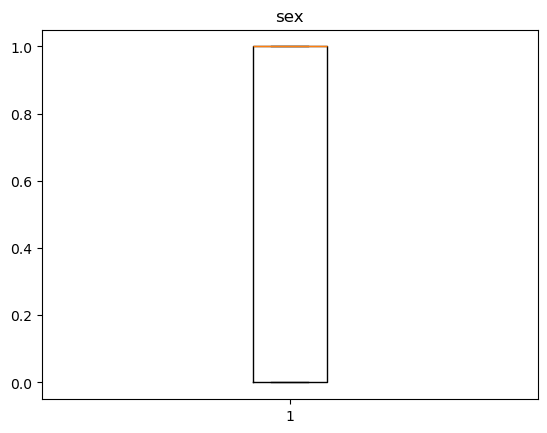

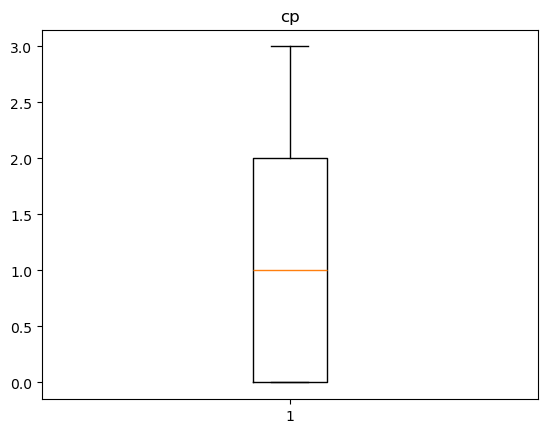

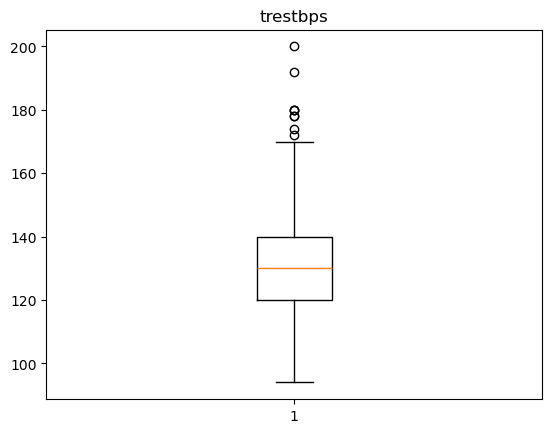

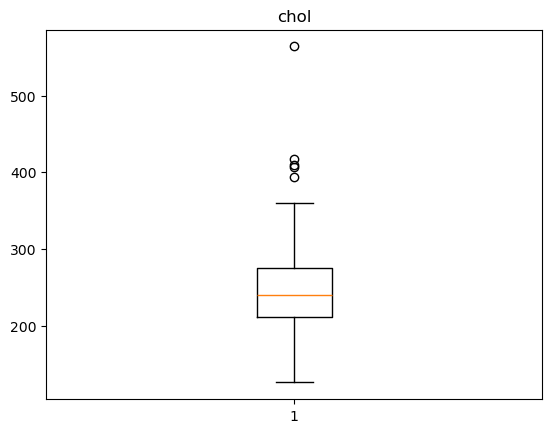

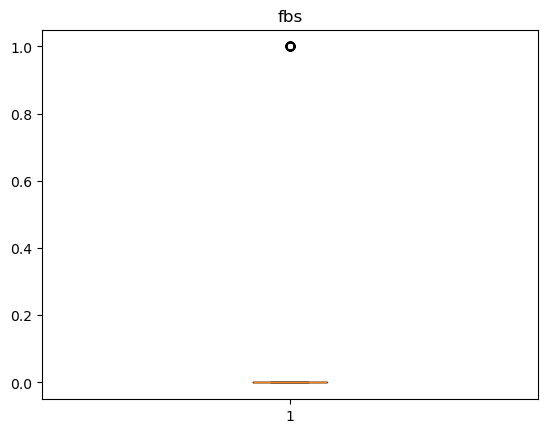

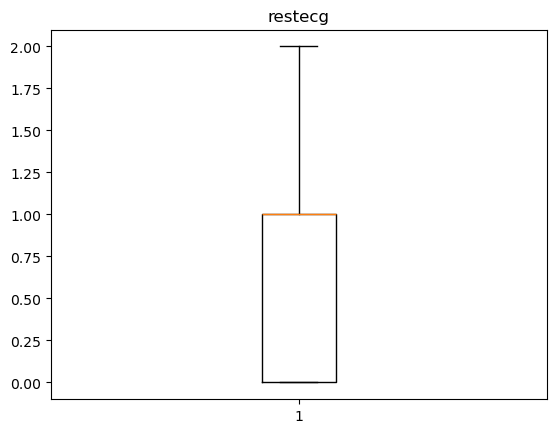

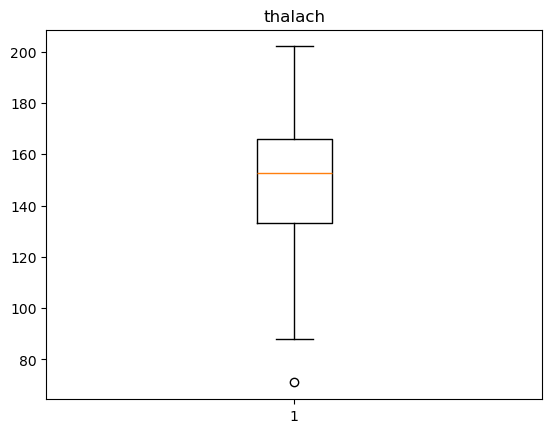

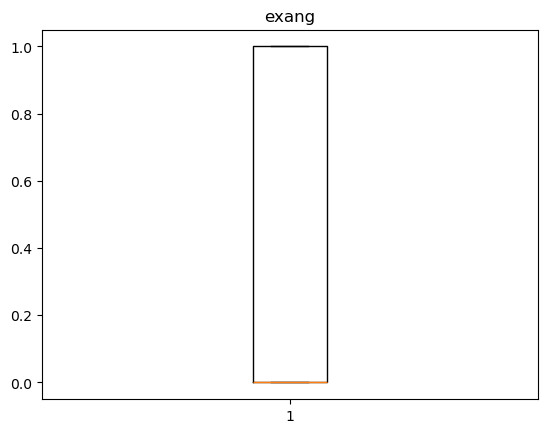

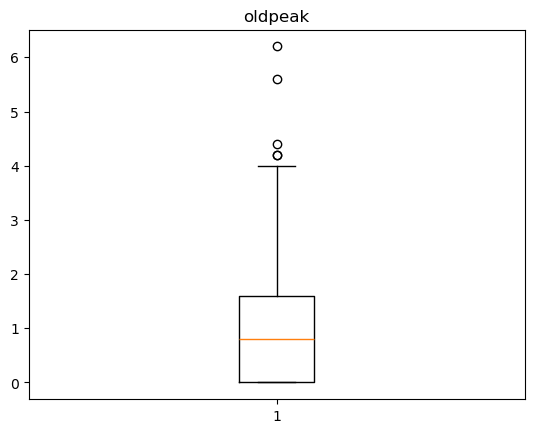

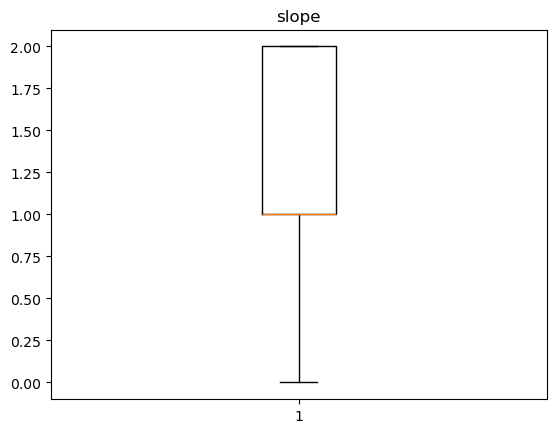

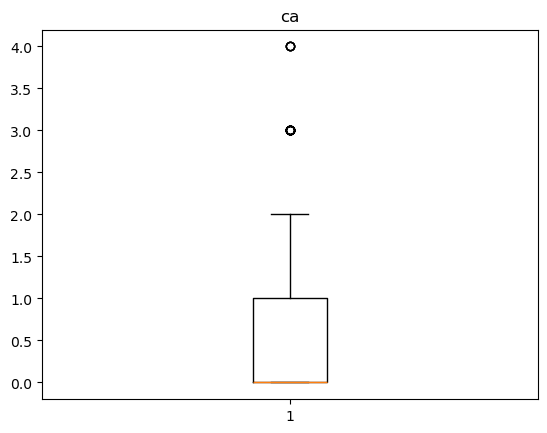

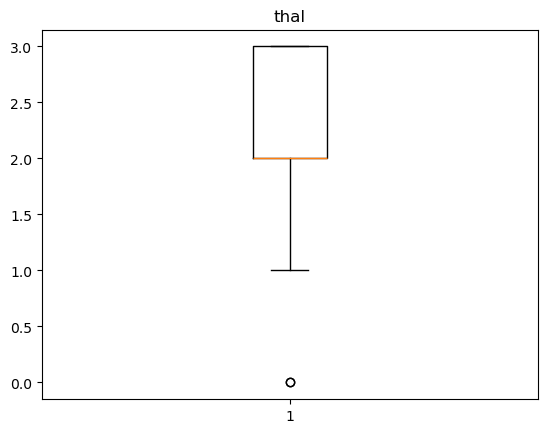

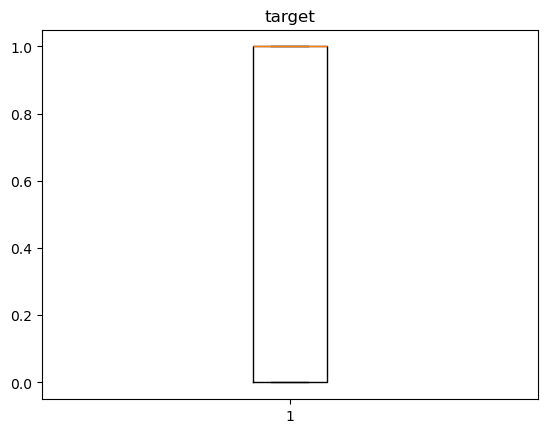

In [21]:
for i in df.columns:
    if df[i].dtype != 'object':
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [25]:
#model building
x = df.iloc[:,:-1]
y = df['target']

In [26]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [27]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 302, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.20,random_state = 42)

In [30]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
203,68,1,2,180,274,1,0,150,1,1.6,1,0,3
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
177,64,1,2,140,335,0,1,158,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,41,1,0,110,172,0,0,158,0,0.0,2,0,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
271,61,1,3,134,234,0,1,145,0,2.6,1,2,2


In [31]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,55,1,0,132,353,0,1,132,1,1.2,1,1,3
229,64,1,2,125,309,0,1,131,1,1.8,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
247,66,1,1,160,246,0,1,120,1,0.0,1,3,1
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,51,1,0,140,298,0,1,122,1,4.2,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2


In [32]:
y_train

132    1
203    0
197    0
75     1
177    0
      ..
189    0
71     1
106    1
271    0
102    1
Name: target, Length: 241, dtype: int64

In [33]:
y_test

180    0
229    0
111    1
247    0
60     1
      ..
250    0
104    1
300    0
194    0
185    0
Name: target, Length: 61, dtype: int64

In [35]:
from sklearn.tree import DecisionTreeClassifier

In [36]:
dt_model = DecisionTreeClassifier()

In [37]:
dt_model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
#test the model
y_pred = dt_model.predict(x_test)
y_pred

array([0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0])

In [39]:
#Evaluating the model
from sklearn.metrics import *

In [40]:
accuracy_score(y_test,y_pred)

0.7704918032786885

In [41]:
precision_score(y_test,y_pred)

0.8461538461538461

In [42]:
recall_score(y_test,y_pred)

0.6875

In [43]:
from sklearn import tree

[Text(0.5851063829787234, 0.9583333333333334, 'x[12] <= 2.5\ngini = 0.495\nsamples = 241\nvalue = [109, 132]'),
 Text(0.3351063829787234, 0.875, 'x[11] <= 0.5\ngini = 0.382\nsamples = 148\nvalue = [38, 110]'),
 Text(0.4601063829787234, 0.9166666666666667, 'True  '),
 Text(0.2127659574468085, 0.7916666666666666, 'x[9] <= 1.7\ngini = 0.208\nsamples = 102\nvalue = [12, 90]'),
 Text(0.1276595744680851, 0.7083333333333334, 'x[0] <= 58.5\ngini = 0.139\nsamples = 93\nvalue = [7, 86]'),
 Text(0.06382978723404255, 0.625, 'x[3] <= 109.0\ngini = 0.028\nsamples = 71\nvalue = [1, 70]'),
 Text(0.0425531914893617, 0.5416666666666666, 'x[1] <= 0.5\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.02127659574468085, 0.4583333333333333, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.06382978723404255, 0.4583333333333333, 'x[9] <= 0.6\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.0425531914893617, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.0851063829787234, 0.375, 'gini = 0

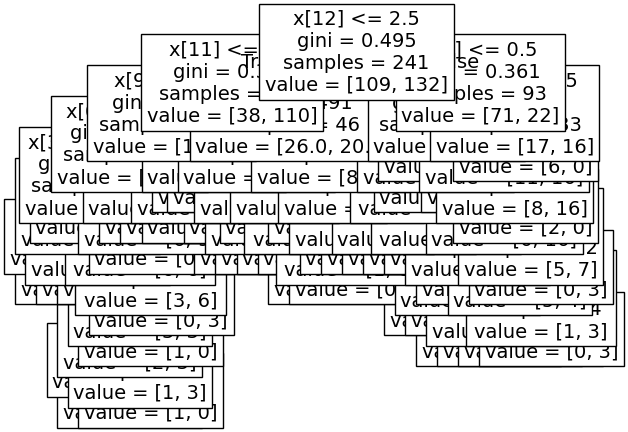

In [45]:
tree.plot_tree(dt_model, fontsize = 14)

In [46]:
dt_model.get_depth()

11

**Variance Inflation Factor (VIF) and Recursive Feature Elimination (RFE) are often skipped with decision trees because trees are naturally immune to multicollinearity and possess built-in feature selection mechanisms**

# Hyperparameters:

A hyperparameter is a setting that you decide before training the model.

Overfitting and Underfitting:

Overfitting:

Overfitting is a condition when my model learns too much as a result its going to give the best result on the training side but didn't perform well on the testing side.

Underfitting:

Underfitting is a condition when my model is too simple as a result its not going tp give the better result either on training side nor on testing side.

1. max_depth: It is used to control the depth of the tree.

**Testing different different max depth to increase the accuracy.**

In [47]:
depths=[1,2,3,4,5,6,7,8,9,10,11,12,13]
for i in depths:
  dt_model=DecisionTreeClassifier(max_depth=i)
  dt_model.fit(x_train,y_train)
  y_pred=dt_model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  print(' For Max Depth',i,'Accuracy Score is:',acc)

 For Max Depth 1 Accuracy Score is: 0.7213114754098361
 For Max Depth 2 Accuracy Score is: 0.7377049180327869
 For Max Depth 3 Accuracy Score is: 0.7868852459016393
 For Max Depth 4 Accuracy Score is: 0.8032786885245902
 For Max Depth 5 Accuracy Score is: 0.819672131147541
 For Max Depth 6 Accuracy Score is: 0.8032786885245902
 For Max Depth 7 Accuracy Score is: 0.7704918032786885
 For Max Depth 8 Accuracy Score is: 0.8032786885245902
 For Max Depth 9 Accuracy Score is: 0.8032786885245902
 For Max Depth 10 Accuracy Score is: 0.7868852459016393
 For Max Depth 11 Accuracy Score is: 0.7868852459016393
 For Max Depth 12 Accuracy Score is: 0.7868852459016393
 For Max Depth 13 Accuracy Score is: 0.7704918032786885


**Accuracy score is the highest for Max depth of 5**